<a href="https://colab.research.google.com/github/robinrj6/ControlNet_revamp/blob/main/notebook_attention-5k_25K.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Dataset management for UNET
- In this, we will use only the 50% (25k) target images of the dataset.

In [ ]:
pip install opencv-python

In [ ]:
!wget https://huggingface.co/datasets/fusing/fill50k/resolve/main/images.zip
!unzip images.zip
!rm images.zip

Streaming output truncated to the last 5000 lines.
  inflating: images/45164.png        
  inflating: images/3468.png         
  inflating: images/44408.png        
  inflating: images/42760.png        
  inflating: images/45431.png        
  inflating: images/7607.png         
  inflating: images/25051.png        
  inflating: images/33164.png        
  inflating: images/23211.png        
  inflating: images/29849.png        
  inflating: images/46520.png        
  inflating: images/6969.png         
  inflating: images/43511.png        
  inflating: images/8776.png         
  inflating: images/44598.png        
  inflating: images/8711.png         
  inflating: images/7442.png         
  inflating: images/23714.png        
  inflating: images/35138.png        
  inflating: images/24725.png        
  inflating: images/803.png          
  inflating: images/5287.png         
  inflating: images/26535.png        
  inflating: images/7861.png         
  inflating: images/24858.png        

In [ ]:
import cv2
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
from torchvision import transforms
import math
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, TensorDataset
%matplotlib inline

In [ ]:
hidden_dim = 32
num_groups = 8 # Splits the N channels into this number
T = 300
batch_size = 16
dataset_size = 25000
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [ ]:
class Fill50kDataset(torch.utils.data.Dataset):
    def __init__(self, folder, dataset_size, transform=None):
        self.folder = folder
        self.dataset_size = dataset_size
        self.transform = transform
        # Filter existing files to avoid errors if some indices are missing
        self.image_paths = [os.path.join(folder, f'{i}.png') for i in range(dataset_size)
                            if os.path.exists(os.path.join(folder, f'{i}.png'))]

    public_methods = ["__len__", "__getitem__"]

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        if self.transform:
            img = self.transform(img)

        # Convert to tensor and normalize to [-1, 1]
        img = torch.from_numpy(img).permute(2, 0, 1).float()
        img = (img / 127.5) - 1.0
        return (img,)

# Define transformation pipeline
transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((64, 64)),
    lambda x: np.array(x)
])

# Create Dataset
full_dataset = Fill50kDataset('images', dataset_size=dataset_size, transform=transform)

# Split into Train and Dev
train_size = int(0.8 * len(full_dataset))
dev_size = len(full_dataset) - train_size
tr_dataset, dev_dataset = torch.utils.data.random_split(full_dataset, [train_size, dev_size])

# Create DataLoaders
tr_loader = DataLoader(tr_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
dev_loader = DataLoader(dev_dataset, batch_size=batch_size, shuffle=False, num_workers=2)

# Time Embedding and Residual block

In [ ]:
# Time step embedding
#t=0 = least noisy, t=T-1

class TimestepMLP(nn.Module):
    # A small two-layer MLP (Linear → SiLU → Linear) that takes the raw sinusoidal embedding vector and projects it into a learned representation.
    # Input size is sinusoidal_dim, output size is hidden_dim.
    # This is the "learned" part of the timestep embedding — the sinusoidal part itself has no learned parameters.
    def __init__(self, sinusoidal_dim, hidden_dim):
        super().__init__()
        self.fc1 = nn.Linear(sinusoidal_dim, hidden_dim)
        self.act = nn.SiLU()
        self.fc2 = nn.Linear(hidden_dim, hidden_dim)

    def forward(self, t_emb):
        # t_emb: (batch, sinusoidal_dim) — output of the sinusoidal function
        x = self.fc1(t_emb)
        x = self.act(x)
        x = self.fc2(x)
        return x  # (batch, hidden_dim)

class TimeEmbedding(nn.Module):
    # The full timestep embedding module. Takes a batch of integer timesteps t (shape (batch,), ranging 0 to T-1)
    # and returns a learned embedding vector per timestep (shape (batch, hidden_dim)).
    # Internally: computes a fixed sinusoidal embedding (sin/cos at different frequencies, same family as transformer positional embeddings),
    # then passes it through TimestepMLP to produce the final learned representation.
    # Instantiated once in the UNet, called once per forward pass, output shared across all residual blocks.
    def __init__(self, sine_dim):
        super().__init__()
        self.sine_dim = sine_dim
        self.mlp = TimestepMLP(sine_dim, hidden_dim) # sine_dim = 8, hidden_dim = 32; better to have hidden_dim > sine_dim. hidden_dim is the output of the MLP

    def sinusoidal_embd(self, t):
        half_dim = self.sine_dim // 2
        freqs = torch.exp(-math.log(10000) * torch.arange(half_dim, device=t.device) / half_dim) # [half_dim] - 1D
        args = t[:, None].float() * freqs[None, :] # t * freqs; just broadcasting to multiply different shapes
        return torch.cat([torch.sin(args), torch.cos(args)], dim=-1)

    def forward(self, t):
        t_sin = self.sinusoidal_embd(t)   # (batch, sinusoidal_dim)
        return self.mlp(t_sin)                  # (batch, hidden_dim)

feature_map = the image at current timestep

In [ ]:
# Residual block

class ResidualBlock(nn.Module):
    # The core building block of the UNet. Takes an image feature map x (shape (batch, in_channels, H, W)) and
    # the timestep embedding t_emb (shape (batch, hidden_dim)) and returns a new feature map (shape (batch, out_channels, H, W)).
    # Internally: two Conv2d 3x3 layers with GroupNorm and SiLU activation, with the timestep embedding injected
    # (via a small linear projection + unsqueeze) between the two convs. A skip connection (x + f(x)) wraps the whole thing
    # — uses a 1x1 Conv2d to match channels if in_channels != out_channels, otherwise Identity.
    def __init__(self, in_channels, out_channels, hidden_dim):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1)
        self.norm1 = nn.GroupNorm(num_groups, out_channels)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1)
        self.norm2 = nn.GroupNorm(num_groups, out_channels)
        self.act = nn.SiLU()
        self.t_proj = nn.Linear(hidden_dim, out_channels)
        self.skip = nn.Conv2d(in_channels, out_channels, kernel_size=1) if in_channels != out_channels else nn.Identity()

    def projTimeEmbd(self, t_emb):
        return self.t_proj(t_emb).unsqueeze(-1).unsqueeze(-1)

    def forward(self, x, t_emb):
        # first conv
        y = self.conv1(x)
        y = self.norm1(y)
        y = self.act(y)
        # inject timestep
        y = y + self.projTimeEmbd(t_emb)
        # second conv
        y = self.conv2(y)
        y = self.norm2(y)
        # skip connection
        y = y + self.skip(x)
        return y


In [ ]:
# block = ResidualBlock(in_channels=3, out_channels=32, hidden_dim=32)
# x = torch.randn(4, 3, 64, 64)       # batch=4, 3 channels, 64x64
# t = torch.randint(0, 300, (4,))
# te = TimeEmbedding(sine_dim=8)
# t_emb = te(t)                        # (4, 32)
# out = block(x, t_emb)
# print(out.shape)                     # expect (4, 32, 64, 64)

# UNet
The UNet is purely a pattern recogniser — "given this noisy image at this noise level, what noise pattern do I see?"

In [ ]:
# downsample block

class DownSample(nn.Module):
    # Halves the spatial resolution of the feature map while increasing channel count. A single Conv2d with stride=2
    # (learnable downsampling, preferred over pooling in diffusion UNets since the kernel weights are trained).
    # Takes (batch, in_channels, H, W) → outputs (batch, out_channels, H/2, W/2).
    # No timestep embedding needed — purely a spatial operation.
    # Used at the end of each contracting stage in the UNet.
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.downsample = nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1, stride=2)

    def forward(self, x):
        return self.downsample(x)

In [ ]:
# ds = DownSample(32, 64)
# x = torch.randn(4, 32, 64, 64)
# out = ds(x)
# print(out.shape) # expect (4, 64, 32, 32) — channels 32→64, spatial 64→32

In [ ]:
# upsample block

class UpSample(nn.Module):
    # Doubles the spatial resolution while decreasing channel count, then concatenates the skip connection from the matching contracting stage.
    # Uses ConvTranspose2d with kernel_size=4, stride=2, padding=1 for exact 2× upsampling (no off-by-one ambiguity).
    # Takes (batch, in_channels, H, W) + skip (batch, skip_channels, H*2, W*2) → outputs (batch, out_channels + skip_channels, H*2, W*2).
    # The subsequent ResidualBlock in the expanding path receives this concatenated tensor as its in_channels.
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.upsample = nn.ConvTranspose2d(in_channels, out_channels, kernel_size=4, stride=2, padding=1)
        # kernel_size=4, stride=2, padding=1 is the standard combination for exact 2× upsampling
        # — produces output exactly double the input spatial size, no off-by-one ambiguity.
    def forward(self, x, skip):
        x = self.upsample(x)
        x = torch.cat([x, skip], dim=1)  # concatenate skip connection along channel dim
        return x

In [ ]:
# us = UpSample(64, 32)
# x = torch.randn(4, 64, 32, 32)
# skip = torch.randn(4, 32, 64, 64)  # from matching contracting stage
# out = us(x, skip)
# print(out.shape)  # expect (4, 64, 64, 64) — 32 up-channels + 32 skip-channels

channels and image resolutions are different things

# Noise Scheduler
The noise scheduler precomputes a table of values for every timestep t from 0 to T-1, so during training you can instantly look up "how much noise belongs at step t" without recomputing anything.
- beta_t      — how much noise to add at this specific step (small number, e.g. 0.0001 to 0.02)
- alpha_t     — how much of the signal remains = 1 - beta_t
- alpha_bar_t — cumulative product of all alphas up to t = α₁ × α₂ × ... × αₜ

alpha_bar_t is the important one — it's what lets you jump directly to "noisy image at step t" in one shot during training, without iterating through all previous steps.

* noisy_image = sqrt(alpha_bar_t) * clean_image + sqrt(1 - alpha_bar_t) * noise

Where noise is random Gaussian noise torch.randn_like(image). As t increases, alpha_bar_t shrinks toward 0 (less clean image) and 1 - alpha_bar_t grows toward 1 (more noise).

In [ ]:
class NoiseScheduler:
    def __init__(self, T=300, beta_start=0.0001, beta_end=0.01):
        self.T = T
        # linearly spaced betas from small to large
        self.beta_t = torch.linspace(beta_start, beta_end, T)
        self.alpha_t = 1 - self.beta_t
        self.alpha_bar_t = torch.cumprod(self.alpha_t, dim=0)

    def add_noise(self, x, t, noise):
        # x: (batch, 3, 64, 64) clean image
        # t: (batch,) integer timesteps
        # noise: (batch, 3, 64, 64) random gaussian
        ab = self.alpha_bar_t[t] # (batchl, )
        a = ab.view( -1, 1, 1, 1)
        noisy_image = torch.sqrt(a) * x + torch.sqrt(1 - a) * noise # noise = torch.randn_like(x) # (batch, 3, 64, 64)—random values from N(0,1)
        return noisy_image


# Self attention

This helps the layer to have previous information. Self-attention lets each spatial position gather information from every other spatial position in the image, weighted by relevance — not just its immediate neighbors (which is all a conv layer can see, since convs only look at a small local kernel window).

A regular conv layer only sees a small local neighborhood (3×3 kernel) — it has no way to directly relate something happening in the top-left corner to something happening in the bottom-right corner, except indirectly through many stacked layers. Attention gives a direct connection between any two spatial positions, regardless of distance.

- `nn.MultiheadAttention` does the QKV attention just packaged as a PyTorch layer — `query=key=value=x` makes it self-attention (each spatial position attends to every other position, including itself)
- `batch_first=True` matches your tensor convention (batch, seq, features)
- The skip connection `(residual + attn_out)` follows the same residual pattern as your `ResidualBlock` — attention layers in modern architectures almost always keep this pattern for the same gradient-flow reasons


In [ ]:
class SelfAttention(nn.Module):
    def __init__(self, channels, num_heads=4):
        super().__init__()
        self.norm = nn.GroupNorm(num_groups, channels)
        self.mha = nn.MultiheadAttention(embed_dim=channels, num_heads=num_heads, batch_first=True)
        self.proj = nn.Linear(channels, channels)

    def forward(self, x):
        B, C, H, W = x.shape
        residual = x

        x = self.norm(x)
        x = x.view(B, C, H * W).permute(0, 2, 1)  # (B, H*W, C) — sequence of spatial tokens

        attn_out, _ = self.mha(x, x, x)  # self-attention: query=key=value=x
        attn_out = self.proj(attn_out)

        attn_out = attn_out.permute(0, 2, 1).view(B, C, H, W)  # back to (B, C, H, W)
        return residual + attn_out  # skip connection, same pattern as ResidualBlock

In [ ]:
class UNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.te = TimeEmbedding(sine_dim=8)

        # Contracting path
        self.resDn1 = ResidualBlock(in_channels=3, out_channels=32, hidden_dim=32)
        self.ds1 = DownSample(in_channels=32, out_channels=64)
        self.resDn2 = ResidualBlock(in_channels=64, out_channels=64, hidden_dim=32)
        self.ds2 = DownSample(in_channels=64, out_channels=128)
        self.resDn3 = ResidualBlock(in_channels=128, out_channels=128, hidden_dim=32)
        self.ds3 = DownSample(in_channels=128, out_channels=256)
        self.resDn4 = ResidualBlock(in_channels=256, out_channels=256, hidden_dim=32)
        self.ds4 = DownSample(in_channels=256, out_channels=512)

        # Bottleneck: 512 channels, 4x4
        self.resBottle = ResidualBlock(in_channels=512, out_channels=512, hidden_dim=32)
        self.attnBottle = SelfAttention(channels=512)

        # Expanding path
        self.us1 = UpSample(in_channels=512, out_channels=256)
        self.resUp1 = ResidualBlock(in_channels=512, out_channels=256, hidden_dim=32)  # 256+256 skip
        self.us2 = UpSample(in_channels=256, out_channels=128)
        self.resUp2 = ResidualBlock(in_channels=256, out_channels=128, hidden_dim=32)  # 128+128 skip
        self.us3 = UpSample(in_channels=128, out_channels=64)
        self.resUp3 = ResidualBlock(in_channels=128, out_channels=64, hidden_dim=32)   # 64+64 skip
        self.us4 = UpSample(in_channels=64, out_channels=32)
        self.resUp4 = ResidualBlock(in_channels=64, out_channels=32, hidden_dim=32)    # 32+32 skip

        self.final_conv = nn.Conv2d(32, 3, kernel_size=1)

    def forward(self, x, t):
        skipconn = []
        t_emb = self.te(t)

        dn1 = self.resDn1(x, t_emb); skipconn.append(dn1); dn1 = self.ds1(dn1)
        dn2 = self.resDn2(dn1, t_emb); skipconn.append(dn2); dn2 = self.ds2(dn2)
        dn3 = self.resDn3(dn2, t_emb); skipconn.append(dn3); dn3 = self.ds3(dn3)
        dn4 = self.resDn4(dn3, t_emb); skipconn.append(dn4); dn4 = self.ds4(dn4)

        bttle = self.resBottle(dn4, t_emb)
        bttle = self.attnBottle(bttle)

        up1 = self.us1(bttle, skipconn[3]); up1 = self.resUp1(up1, t_emb)
        up2 = self.us2(up1, skipconn[2]); up2 = self.resUp2(up2, t_emb)
        up3 = self.us3(up2, skipconn[1]); up3 = self.resUp3(up3, t_emb)
        up4 = self.us4(up3, skipconn[0]); up4 = self.resUp4(up4, t_emb)

        return self.final_conv(up4)

In [ ]:
# model = UNet()
# x = torch.randn(4, 3, 64, 64)
# t = torch.randint(0, 300, (4,))
# out = model(x, t)
# print(out.shape)  # expect (4, 3, 64, 64)
attn = SelfAttention(channels=512)
x = torch.randn(4, 512, 4, 4)
out = attn(x)
print(out.shape)  # expect (4, 512, 4, 4) — same shape in and out

torch.Size([4, 512, 4, 4])


# Training loop

1. sample random t per image
2. sample random noise
3. call add_noise
4. pass noisy image + t into UNet
5. MSE between predicted noise and actual noise

In [ ]:
model = UNet()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
scheduler = NoiseScheduler(T=300, beta_start=0.0001, beta_end=0.02)
scheduler.alpha_bar_t = scheduler.alpha_bar_t.to(device)
losses = []
model = model.to(device)

In [ ]:

# training loop
for epoch in range(5000):
  # validation on every 100 epochs
  if epoch % 100 == 0:
    val_losses = []
    with torch.no_grad():
      for (x,) in dev_loader:
          x, t = x.to(device), torch.randint(0, T, (x.shape[0],)).to(device)
          noise = torch.randn_like(x)
          noisy_img = scheduler.add_noise(x, t, noise)
          pred_noise = model(noisy_img, t)
          val_loss = F.mse_loss(pred_noise, noise)
          val_losses.append(val_loss.item())
    print(f'epoch {epoch} | val loss {sum(val_losses)/len(val_losses):.4f}')
    model.train()

    for (x,) in tr_loader:
        x = x.to(device)
        t = torch.randint(0, 300, (x.shape[0],))
        t = t.to(device)
        noise = torch.randn_like(x)
        noise = noise.to(device)
        noisy_img = scheduler.add_noise(x, t, noise)
        noisy_img = noisy_img.to(device)
        pred_noise = model(noisy_img, t)
        loss = F.mse_loss(pred_noise, noise)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        losses.append(loss.item())

    print(f'epoch {epoch} | train loss {losses[-1]:.4f}')


epoch 0 | val loss 1.2958
epoch 0 | train loss 0.0392
epoch 100 | val loss 0.0433
epoch 100 | train loss 0.0129
epoch 200 | val loss 0.0234
epoch 200 | train loss 0.0100
epoch 300 | val loss 0.0176
epoch 300 | train loss 0.0079
epoch 400 | val loss 0.0139
epoch 400 | train loss 0.0110
epoch 500 | val loss 0.0136
epoch 500 | train loss 0.0119
epoch 600 | val loss 0.0102
epoch 600 | train loss 0.0163
epoch 700 | val loss 0.0108
epoch 700 | train loss 0.0075
epoch 800 | val loss 0.0099
epoch 800 | train loss 0.0052
epoch 900 | val loss 0.0082
epoch 900 | train loss 0.0063
epoch 1000 | val loss 0.0077
epoch 1000 | train loss 0.0070
epoch 1100 | val loss 0.0073
epoch 1100 | train loss 0.0066
epoch 1200 | val loss 0.0086
epoch 1200 | train loss 0.0039
epoch 1300 | val loss 0.0068
epoch 1300 | train loss 0.0058
epoch 1400 | val loss 0.0063
epoch 1400 | train loss 0.0060
epoch 1500 | val loss 0.0061
epoch 1500 | train loss 0.0059
epoch 1600 | val loss 0.0065
epoch 1600 | train loss 0.0043
epoc

In [ ]:
len(losses)

62500

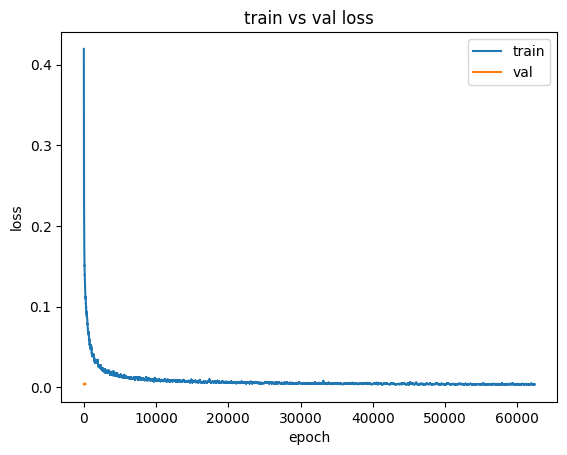

In [ ]:
window_size = 100

# Calculate moving average
moving_avg = np.convolve(losses, np.ones(window_size)/window_size, mode='valid')
moving_avg_val = np.convolve(val_losses, np.ones(window_size)/window_size, mode='valid')

# Plot the smoothed curve
plt.plot(moving_avg, label='train')
plt.plot(moving_avg_val, label='val')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend()
plt.title('train vs val loss')
plt.show()


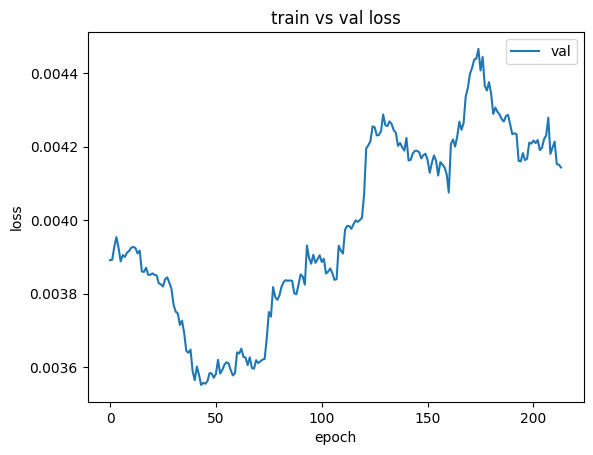

In [ ]:
moving_avg = np.convolve(val_losses, np.ones(window_size)/window_size, mode='valid')
plt.plot(moving_avg, label='val')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend()
plt.title('train vs val loss')
plt.show()

In [ ]:
def sample(model, scheduler, num_samples=4, img_size=64, device='cuda'):
    model.eval()
    with torch.no_grad():
        # Start from pure noise
        x = torch.randn((num_samples, 3, img_size, img_size)).to(device)

        # Iterate backwards from T-1 down to 0
        for t in reversed(range(scheduler.T)):
            t_batch = torch.full((num_samples,), t, device=device, dtype=torch.long)

            # Predict noise using the UNet
            pred_noise = model(x, t_batch)

            # Get scheduler parameters for current t
            alpha = scheduler.alpha_t[t].to(device)
            alpha_bar = scheduler.alpha_bar_t[t].to(device)
            beta = scheduler.beta_t[t].to(device)

            # Compute the reverse step
            if t > 0:
                noise = torch.randn_like(x)
            else:
                noise = 0

            # x_{t-1} formula
            x = (1 / torch.sqrt(alpha)) * (x - ((1 - alpha) / torch.sqrt(1 - alpha_bar)) * pred_noise) + torch.sqrt(beta) * noise

    # Post-process: map from [-1, 1] back to [0, 1]
    x = (x.clamp(-1, 1) + 1) / 2
    return x.cpu()

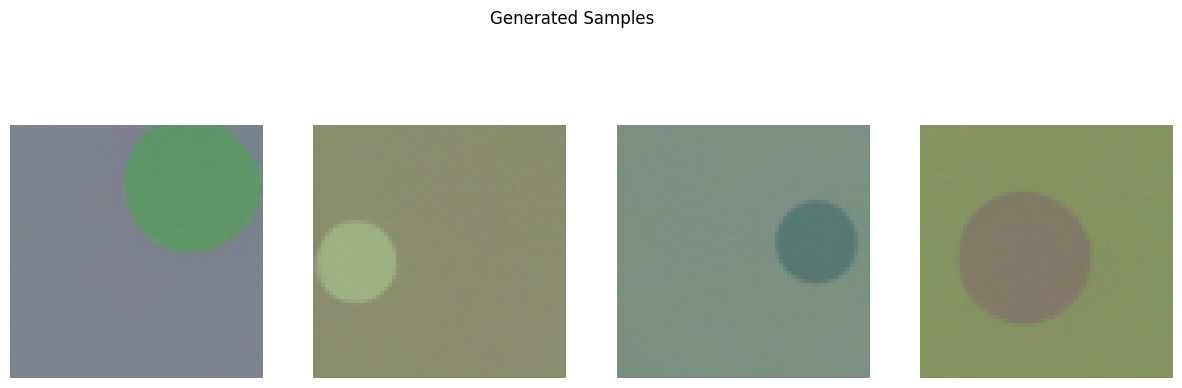

In [ ]:
# Generate samples
samples = sample(model, scheduler, num_samples=4, device=device)

# Visualize
fig, axes = plt.subplots(1, 4, figsize=(15, 5))
for i in range(4):
    axes[i].imshow(samples[i].permute(1, 2, 0).numpy())
    axes[i].axis('off')
plt.suptitle("Generated Samples")
plt.show()